# Volatility Forecasting with LSTMs — Demo

Loads the **pre-trained model shipped in `models/`** and evaluates it on three stocks held out from training: **AMZN**, **META**, **LLY**. Runtime: under two minutes (no training).

**Pipeline**: load shipped model → fetch held-out OHLC + VIX → engineer features → scale with the train-fitted scalers → window → predict → compare against the naive *next-week-≈-this-week* baseline.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data_loader, evaluate, features, train


## 1 · Load the trained model

`load_artifacts()` returns the Keras model, the fitted scalers, and the training metadata in one call. The metadata is the provenance record — it tells you exactly which tickers, hyperparameters, and metrics produced this model.

In [2]:
model, scalers, metadata = train.load_artifacts(config.MODELS_DIR)

# Render the metadata as a tidy two-column table instead of raw JSON
def _flatten(d, prefix=''):
    out = {}
    for k, v in d.items():
        key = f'{prefix}{k}'
        if isinstance(v, dict):
            out.update(_flatten(v, prefix=f'{key}.'))
        elif isinstance(v, list):
            out[key] = ', '.join(map(str, v))
        else:
            out[key] = v
    return out

pd.Series(_flatten(metadata), name='value').to_frame()


,value
trained_on,2026-04-29T21:14:50
tickers,"TSLA, NVDA, AAPL, MSFT, GOOGL, BRK-B, JNJ, KO,..."
use_vix,True
window_size,30
forecast_horizon,5
input_cols,"Volume, return, daily_range, daily_volatility,..."
target_col,target_volatility
lstm_units,32
dense_units,16
dropout,0.3


## 2 · Holdout-evaluation helper

One function for the whole inference path on a single ticker, so each holdout below is a single call.

In [3]:
def evaluate_holdout(ticker: str, vix: pd.DataFrame) -> dict:
    """Fetch -> engineer -> scale -> window -> predict -> metrics -> plot."""
    raw = data_loader.fetch_ohlc(ticker, cache_dir=config.DATA_CACHE_DIR)
    df  = features.engineer_features(raw, vix)
    df  = scalers.transform(df)
    X, y = features.make_windows(
        df, metadata['input_cols'], metadata['target_col'],
        window_size=metadata['window_size'],
    )
    res = evaluate.evaluate_on_split(
        model, X, y, scalers, input_cols=metadata['input_cols'],
    )
    print(f"{ticker}  (n_windows = {len(X):,})")
    print(f"  Model  RMSE = {res['model']['rmse']:.5f}  R\u00b2 = {res['model']['r2']:.3f}  MAE = {res['model']['mae']:.5f}")
    print(f"  Naive  RMSE = {res['naive']['rmse']:.5f}  R\u00b2 = {res['naive']['r2']:.3f}  MAE = {res['naive']['mae']:.5f}")
    print(f"  Improvement: {res['improvement_pct']:+.1f}%")
    evaluate.plot_predictions_timeseries(
        res['y_true_real'], res['y_pred_real'],
        title=f"{ticker}: Predicted vs Actual Volatility (held-out)",
    )
    evaluate.plot_actual_vs_predicted_scatter(
        res['y_true_real'], res['y_pred_real'],
        title=f"{ticker}: Predicted vs Actual",
    )
    plt.show()
    return res


## 3 · Fetch VIX once (shared across all holdout stocks)

In [4]:
vix = data_loader.fetch_vix(cache_dir=config.DATA_CACHE_DIR)
print(f"VIX rows: {len(vix):,}  |  range: {vix.index.min().date()} \u2192 {vix.index.max().date()}")


VIX rows: 9,148  |  range: 1990-01-02 → 2026-04-29


## 4 · Held-out evaluations

### Amazon — AMZN

AMZN  (n_windows = 6,999)
  Model  RMSE = 0.03883  R² = 0.369  MAE = 0.02333
  Naive  RMSE = 0.04897  R² = -0.004  MAE = 0.03052
  Improvement: +20.7%


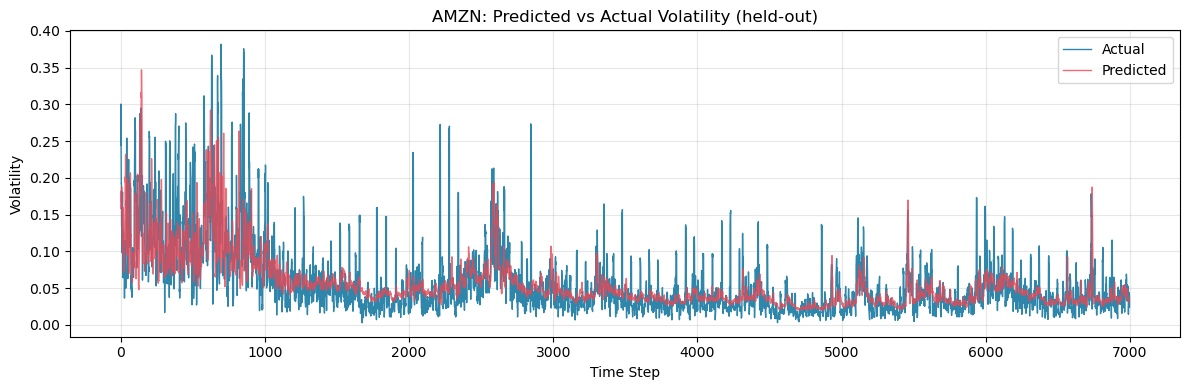

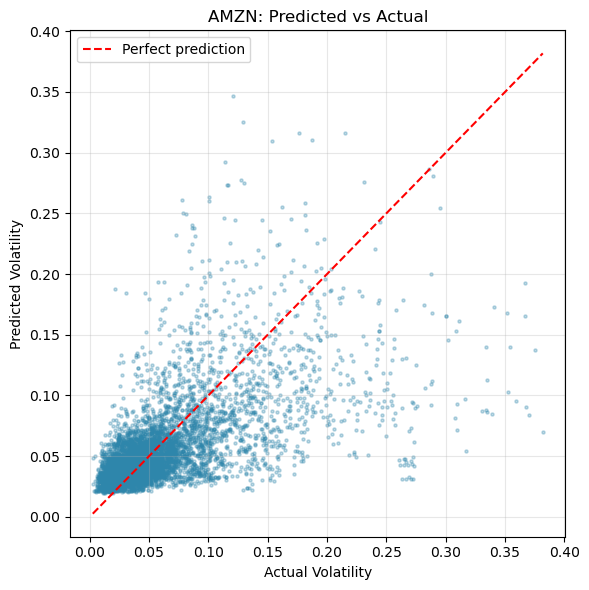

In [5]:
amzn_results = evaluate_holdout('AMZN', vix)

### Meta — META

META  (n_windows = 3,221)
  Model  RMSE = 0.02959  R² = 0.169  MAE = 0.01749
  Naive  RMSE = 0.03990  R² = -0.510  MAE = 0.02386
  Improvement: +25.8%


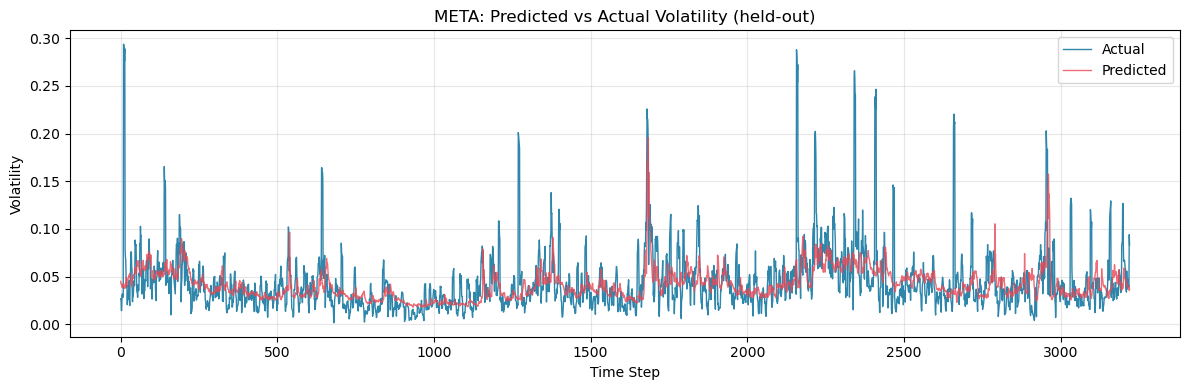

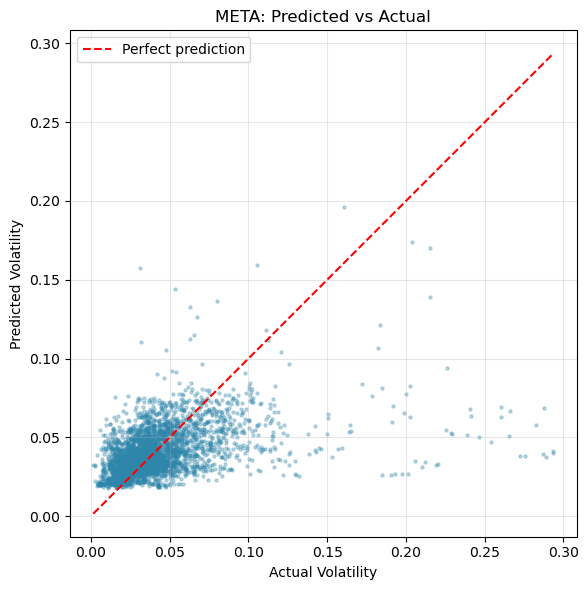

In [6]:
meta_results = evaluate_holdout('META', vix)

### Eli Lilly — LLY

LLY  (n_windows = 9,096)
  Model  RMSE = 0.01942  R² = 0.276  MAE = 0.01301
  Naive  RMSE = 0.02631  R² = -0.328  MAE = 0.01715
  Improvement: +26.2%


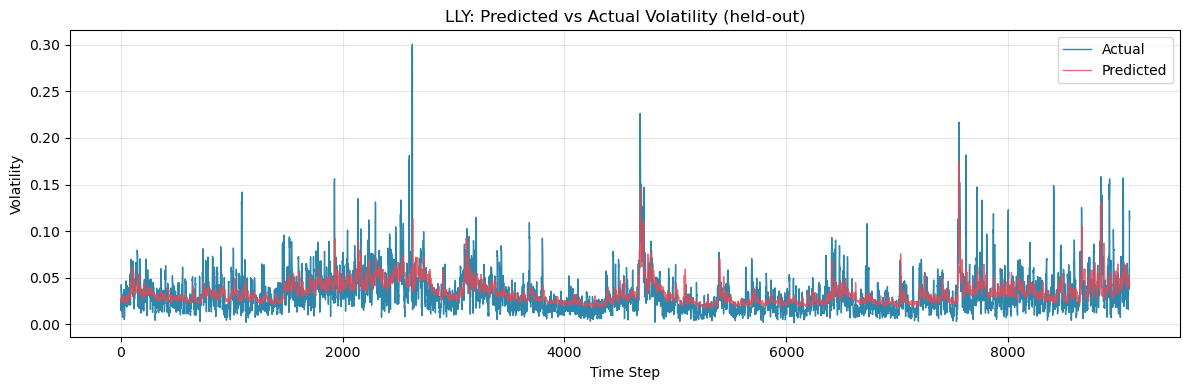

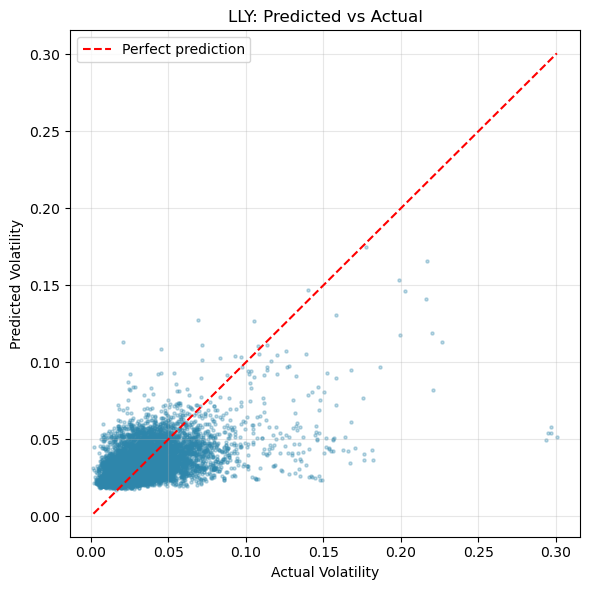

In [7]:
lly_results = evaluate_holdout('LLY', vix)

## 5 · Summary: model vs naive across all three holdouts

Side-by-side RMSE comparison across the three held-out stocks. The LSTM's value-add is the gap below the grey naive bars.

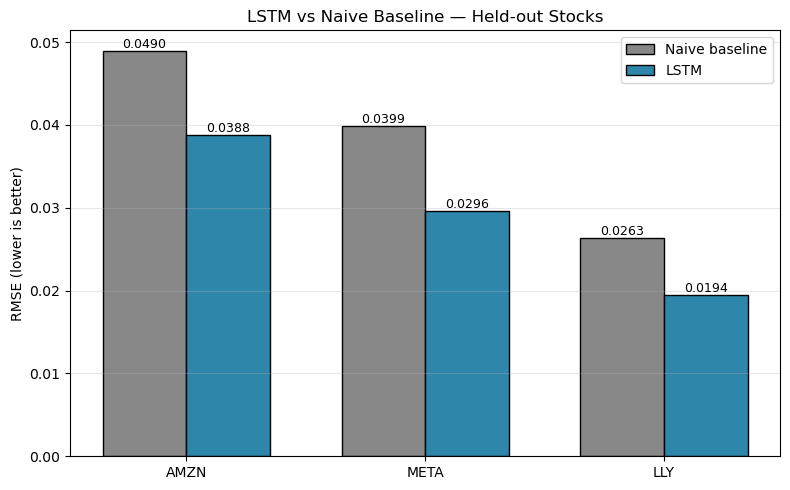

,Ticker,Naive RMSE,Model RMSE,Improvement (%),Model R²
0,AMZN,0.04897,0.03883,+20.7,0.369
1,META,0.03990,0.02959,+25.8,0.169
2,LLY,0.02631,0.01942,+26.2,0.276


In [8]:
all_results = {
    'AMZN': amzn_results,
    'META': meta_results,
    'LLY':  lly_results,
}

labels = list(all_results.keys())
model_rmse = [r['model']['rmse'] for r in all_results.values()]
naive_rmse = [r['naive']['rmse'] for r in all_results.values()]

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, naive_rmse, w, label='Naive baseline', color='#888888', edgecolor='black')
b2 = ax.bar(x + w/2, model_rmse, w, label='LSTM',           color='#2E86AB', edgecolor='black')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('RMSE (lower is better)')
ax.set_title('LSTM vs Naive Baseline \u2014 Held-out Stocks')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Ticker':           labels,
    'Naive RMSE':       [f'{r:.5f}' for r in naive_rmse],
    'Model RMSE':       [f'{r:.5f}' for r in model_rmse],
    'Improvement (%)':  [f"{r['improvement_pct']:+.1f}" for r in all_results.values()],
    'Model R\u00b2':    [f"{r['model']['r2']:.3f}" for r in all_results.values()],
})
summary


---

See the project README for retraining (`python -m src.train`) and the unit test suite (`pytest -v`).